# Notebook 2 — Saliency Mapping

**Goal:** Identify structurally redundant tokens across DiT-XL/2 layers and
denoising timesteps via **attention rollout** (Abnar & Zuidema, 2020).

**Output artefacts:**
- Attention maps captured per layer per timestep
- Rollout importance scores shape (T, 256)
- Binary pruning masks `results/saliency_maps/mask_t{i}.npy`
- Token-grid PNGs `results/saliency_maps/token_grid_ddim_t{t}.png`
- W&B artifact `saliency-masks`

**W&B run:** `saliency-ddim20`

**Reference:** Abnar & Zuidema, *Quantifying Attention Flow in Transformers*, ACL 2020.

## Cell 1 — Imports + wandb Init

Load model and initialise the saliency W&B run.

**Expected output:** config table + W&B run URL.

In [1]:
import sys
import os
from pathlib import Path

os.chdir(os.path.abspath('..'))

# --- Add DiT repo to path ---
sys.path.insert(0, os.path.abspath('DiT'))

import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from utils import config, dit_helpers, viz, wandb_utils
from utils.dit_helpers import seed_everything

seed_everything(config.SEED)

model, vae, diffusion = dit_helpers.load_model(config)

run = wandb_utils.init_run(
    run_name="saliency-ddim20",
    tags=["saliency", "ddim"],
    config_override={"sampler": "ddim", "steps": config.DDIM_STEPS},
)

┌───────────────────────┬──────────────────┐
│            DiT Thesis — Config           │
├───────────────────────┼──────────────────┤
│ Device                │ cuda             │
│ Image size            │ 256              │
│ DDPM steps            │ 250              │
│ DDIM steps            │ 20               │
│ Samples (quick)       │ 50               │
│ Samples (FID)         │ 10000            │
│ wandb project         │ dit-token-prun... │
└───────────────────────┴──────────────────┘
Loading DiT-XL/2 from pretrained_models/DiT-XL-2-256x256.pt...


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


DiT-XL/2 loaded: 675M params
Loading VAE from pretrained_models/sd-vae-ft-ema...


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


VAE loaded: 84M params
Diffusion schedule: DDPM, 1000 steps


wandb: Currently logged in as: rahul23082001jha to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


wandb run initialized: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/3bzeig7c


## Cell 2 — Register Attention Hooks

Attach `register_forward_hook` to every self-attention layer in the 28 DiT blocks.
Captured maps are stored in `attn_store[(layer_idx, timestep)]`.
We store the raw softmax attention weights (after head averaging).

**Expected output:**
```
Registered hooks on 28 attention layers
Storage dict initialized: attn_store
```

In [2]:
attn_store = {}        # {(layer_idx, timestep): np.ndarray (n_heads, seq, seq)}
_current_timestep = [0]   # mutable container for hook closure
_hooks = []

def _make_attn_hook(layer_idx):
    """Capture pre-dropout attention weights from attn_drop input."""
    def hook(module, input, output):
        t = _current_timestep[0]
        if input and input[0] is not None:
            # input[0]: (B, heads, seq, seq) — softmax weights before dropout
            attn_store[(layer_idx, t)] = (
                input[0].detach().cpu().float().numpy()
            )
    return hook

# Register hooks on each DiT block's attn_drop sub-module.
# We also force fused_attn=False so the manual path (which calls attn_drop)
# is always taken; F.scaled_dot_product_attention never exposes weights.
n_hooked = 0
for block_idx, block in enumerate(model.blocks):
    block.attn.fused_attn = False   # force explicit softmax path
    hook = block.attn.attn_drop.register_forward_hook(
        _make_attn_hook(block_idx)
    )
    _hooks.append(hook)
    n_hooked += 1

print(f"Registered hooks on {n_hooked} attention layers")
print(f"Storage dict initialized: attn_store")

Registered hooks on 28 attention layers
Storage dict initialized: attn_store


## Cell 3 — Capture Attention Maps (DDIM-20)

Run one full DDIM-20 denoising trajectory for a single image.
For each of the 20 timesteps, the hooks populate `attn_store` across all 28 layers.

Visualisation 6: 4-layer × 4-timestep attention map grid.

**Expected output:**
```
Captured: 20 timesteps × 28 layers = 560 attention maps
Shape per map: (1, num_heads, 256, 256)
```

  0%|          | 0/20 [00:00<?, ?it/s]

Captured: 20 timesteps × 28 layers = 560 attention maps
Shape per map: (1, 16, 256, 256)


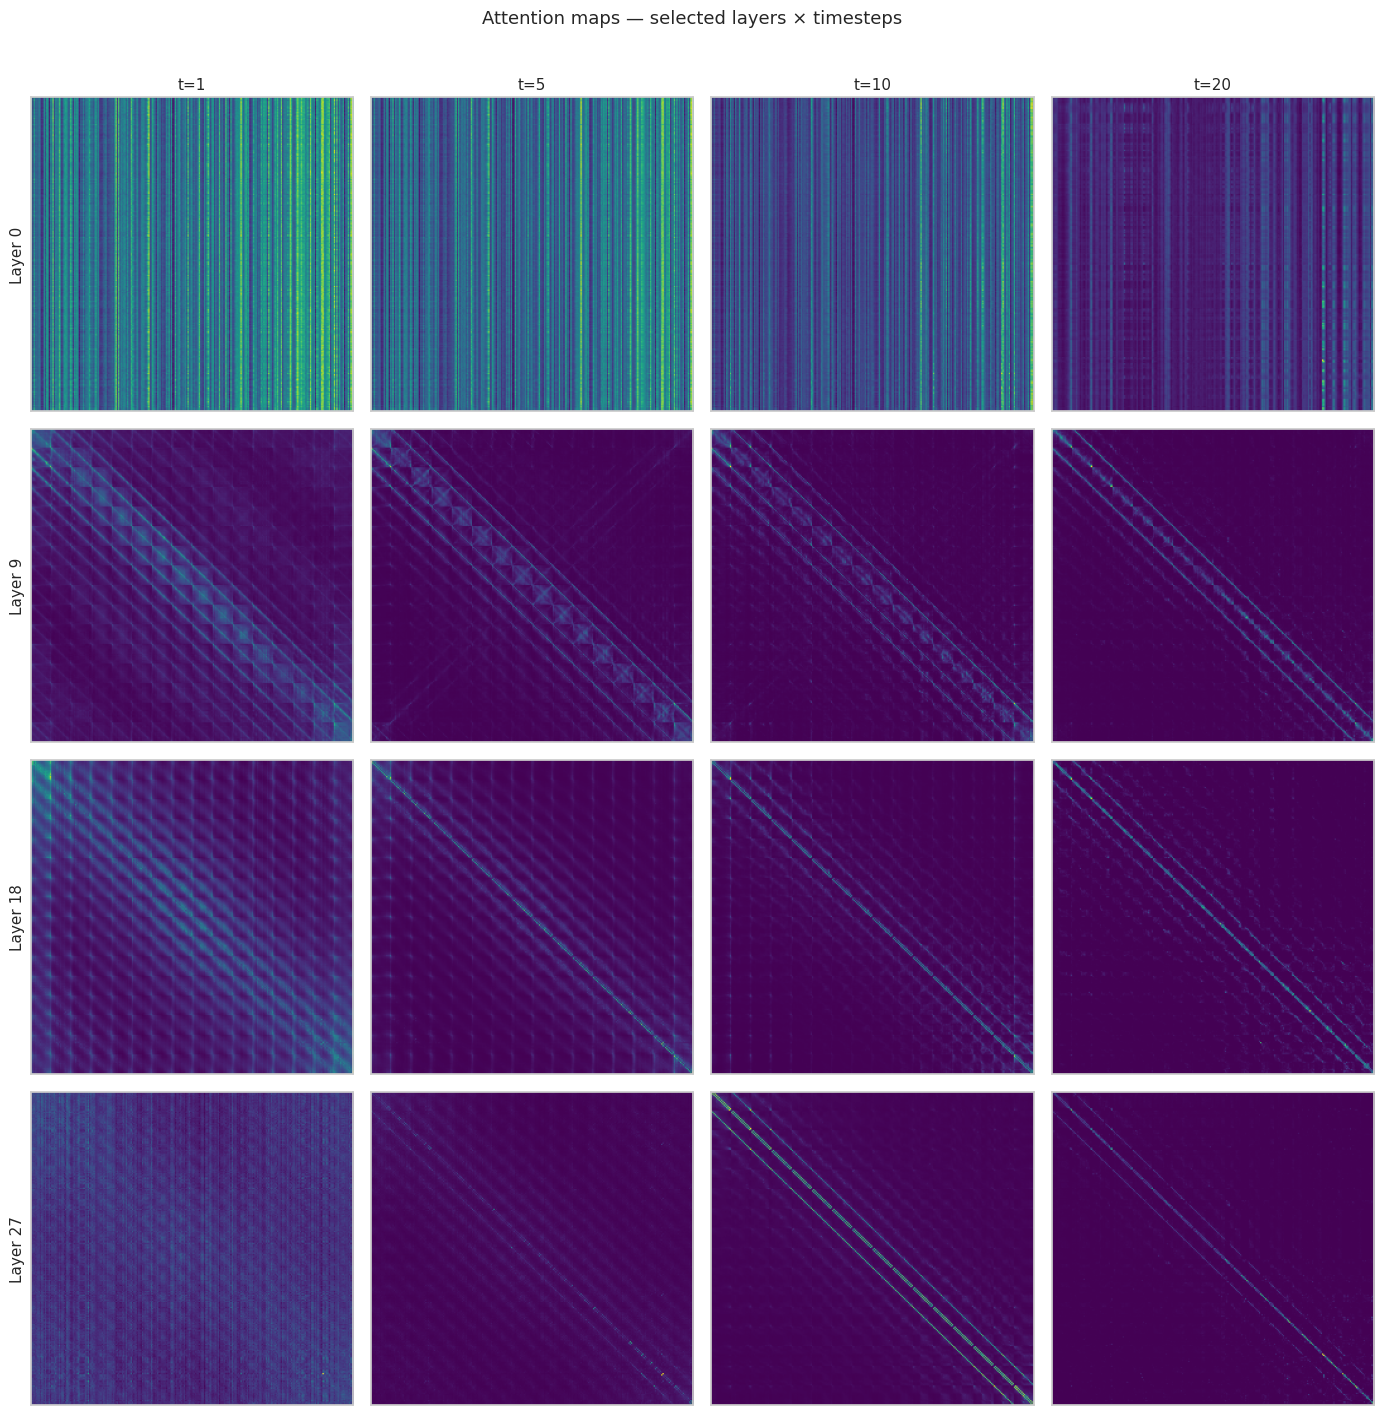

In [3]:
from diffusion import create_diffusion

seed_everything(config.SEED)
device = config.DEVICE
n_steps = config.DDIM_STEPS

sample_diffusion = create_diffusion(timestep_respacing=f"ddim{n_steps}")

# Single image, class 207 (golden retriever — good for visualisation)
z  = torch.randn(1, 4, config.LATENT_SIZE, config.LATENT_SIZE, device=device)
y  = torch.tensor([207], device=device)

# Wrap model forward so we can update _current_timestep inside the loop
step_counter = [0]
timestep_seq = list(sample_diffusion.timestep_map)   # DDIM sub-sampled t values

original_forward = model.forward

def _tracked_forward(x, t, y, **kwargs):
    step_idx = step_counter[0]
    _current_timestep[0] = step_idx + 1   # 1-indexed for readability
    out = original_forward(x, t, y, **kwargs)
    step_counter[0] += 1
    return out

model.forward = _tracked_forward

with torch.no_grad():
    sample = sample_diffusion.ddim_sample_loop(
        model,
        z.shape,
        z,
        clip_denoised=False,
        model_kwargs={"y": y},
        progress=True,
        device=device,
    )

# Restore original forward
model.forward = original_forward

n_maps = len(attn_store)
print(f"Captured: {n_steps} timesteps × {n_hooked} layers = {n_maps} attention maps")

# Verify shape of first map
first_key = list(attn_store.keys())[0]
print(f"Shape per map: {attn_store[first_key].shape}")

# Visualization 6: 4 layers × 4 timesteps attention grid
# Convert stored maps to averaged-across-heads for display
attn_store_avg = {
    k: v.mean(axis=1)[0]   # (seq, seq) — avg heads, remove batch dim
    for k, v in attn_store.items()
}

fig = viz.plot_attention_grid(
    attn_store_avg,
    layers=[0, 9, 18, 27],
    timesteps=[1, 5, 10, 20],
    title="Attention maps — selected layers × timesteps",
)
wandb_utils.log_figure(fig, name="attention_map_grid")

## Cell 4 — Attention Rollout

Compute **attention rollout** (Abnar & Zuidema 2020) per timestep:

```
rollout_t = A_L ⊗ A_{L-1} ⊗ ... ⊗ A_1
```

Before each multiplication, add the identity matrix to account for residual connections:

```
Ã_l = 0.5 * A_l + 0.5 * I
```

The first row of the rollout matrix (CLS/mean token row) gives per-token importance.

Result: `importance_scores` shape `(20, 256)`.

Visualisation 7: violin plot of importance distribution across timesteps.

**Expected output:**
```
Rollout complete: shape (20, 256)
```

Rollout:   0%|          | 0/20 [00:00<?, ?it/s]

Rollout complete: shape (20, 256)


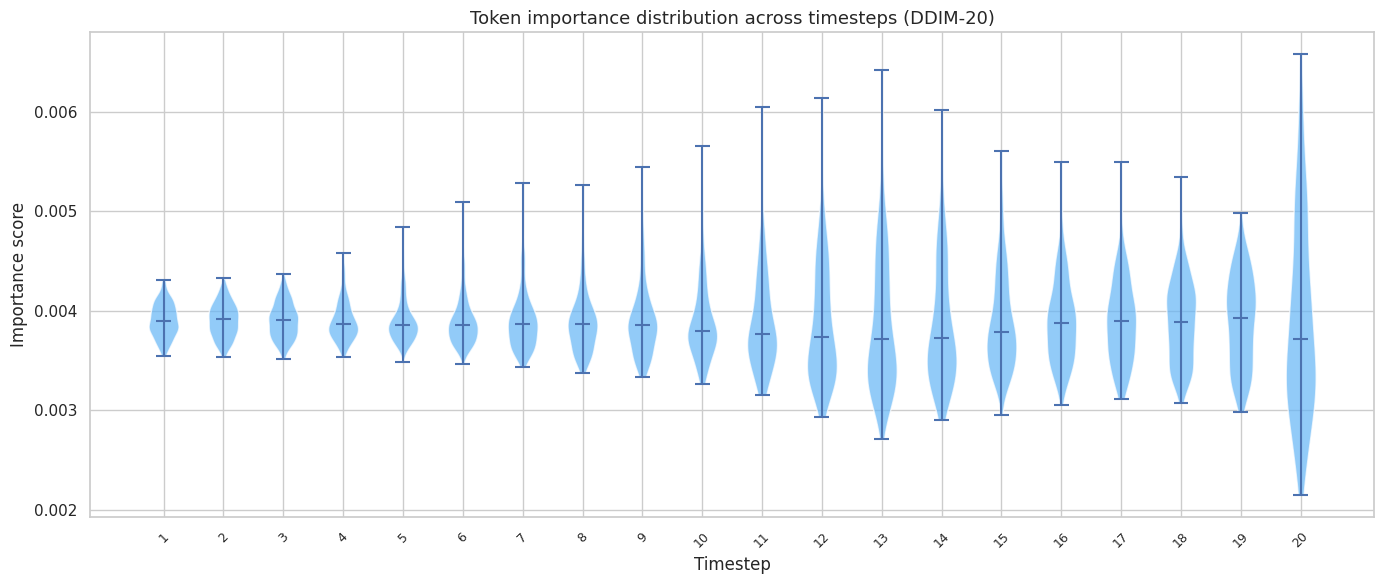

wandb: WARNING Tried to log to step 0 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


In [4]:
def attention_rollout(attn_store, n_timesteps, n_layers):
    """Compute per-timestep attention rollout across all layers.

    Args:
        attn_store (dict): {(layer_idx, timestep): np.ndarray (B, H, S, S)}.
        n_timesteps (int): Number of denoising timesteps.
        n_layers (int): Number of DiT blocks.

    Returns:
        np.ndarray: shape (n_timesteps, S) — importance score per token.
    """
    S = None
    importance_scores = []

    for t in tqdm(range(1, n_timesteps + 1), desc="Rollout"):
        rollout = None
        for l in range(n_layers):
            key = (l, t)
            if key not in attn_store:
                continue
            A = attn_store[key]          # (B, H, S, S)
            A = A.mean(axis=1)[0]        # average heads → (S, S)
            S = A.shape[0]
            # Add residual identity
            A_hat = 0.5 * A + 0.5 * np.eye(S)
            # Row-normalise
            A_hat = A_hat / (A_hat.sum(axis=-1, keepdims=True) + 1e-8)
            if rollout is None:
                rollout = A_hat
            else:
                rollout = rollout @ A_hat

        if rollout is None:
            importance_scores.append(np.zeros(S or config.NUM_TOKENS))
        else:
            # Use the mean of all query rows (no CLS in DiT)
            importance_scores.append(rollout.mean(axis=0))

    return np.array(importance_scores)   # (T, S)


importance_scores = attention_rollout(
    attn_store,
    n_timesteps=n_steps,
    n_layers=n_hooked,
)
print(f"Rollout complete: shape {importance_scores.shape}")

# Visualization 7: violin plot
fig = viz.plot_importance_violin(
    importance_scores,
    timesteps=list(range(1, n_steps + 1)),
    title="Token importance distribution across timesteps (DDIM-20)",
)
wandb_utils.log_figure(fig, name="importance_distribution_violin")

wandb_utils.log_metrics({
    "mean_importance_t1":  float(importance_scores[0].mean()),
    "mean_importance_t20": float(importance_scores[-1].mean()),
}, step=0)

## Cell 5 — Token Grid Heatmaps

Reshape each importance vector (256,) → (16, 16) and plot as a spatial heatmap.
Save PNG files to `config.SALIENCY_DIR`.

Visualisation 8: 2×2 panel combining all four individual token grids.

**Expected output:**
- 4 individual heatmaps (t=1, 5, 10, 20)
- One 2×2 panel

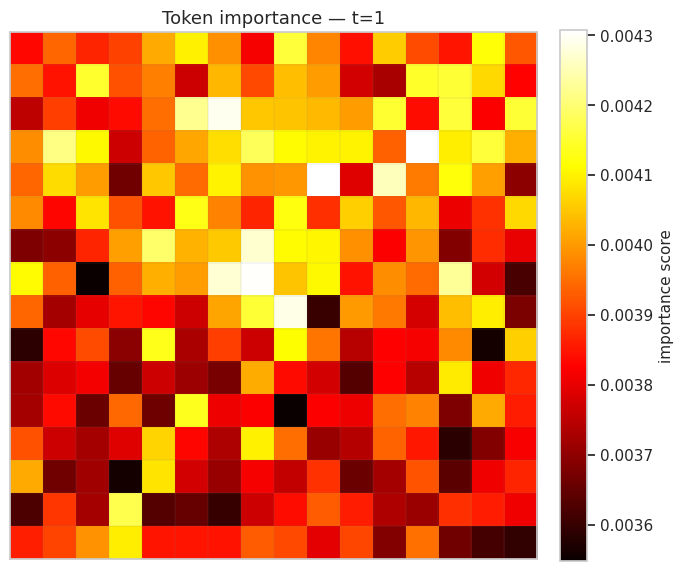

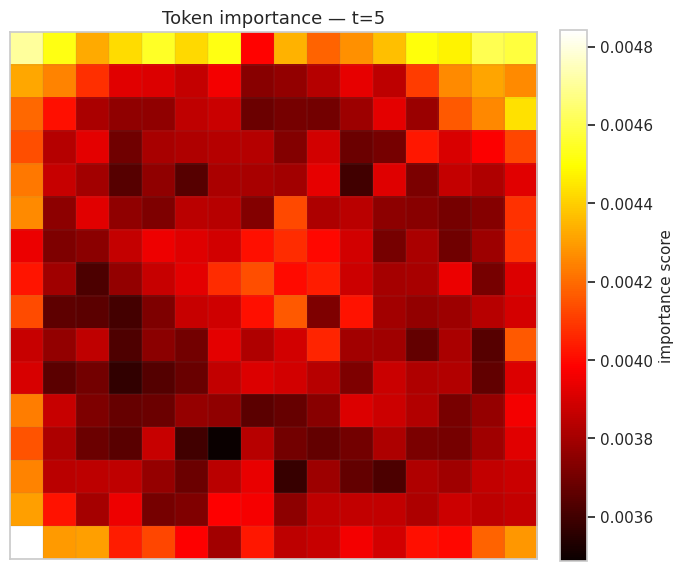

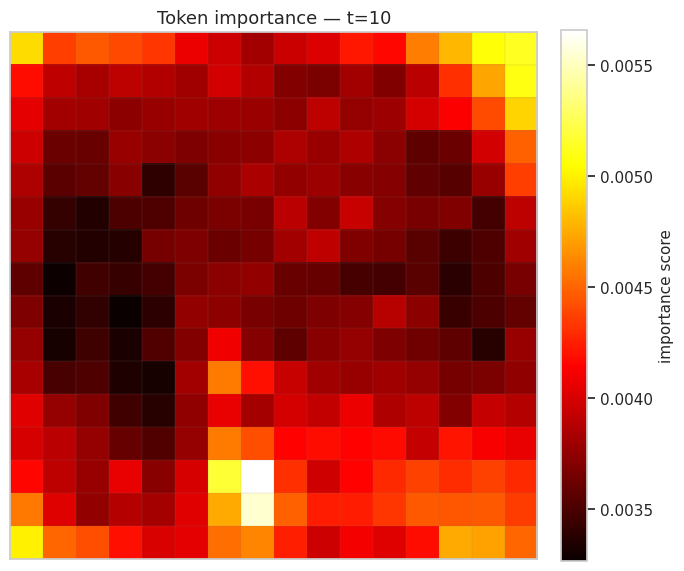

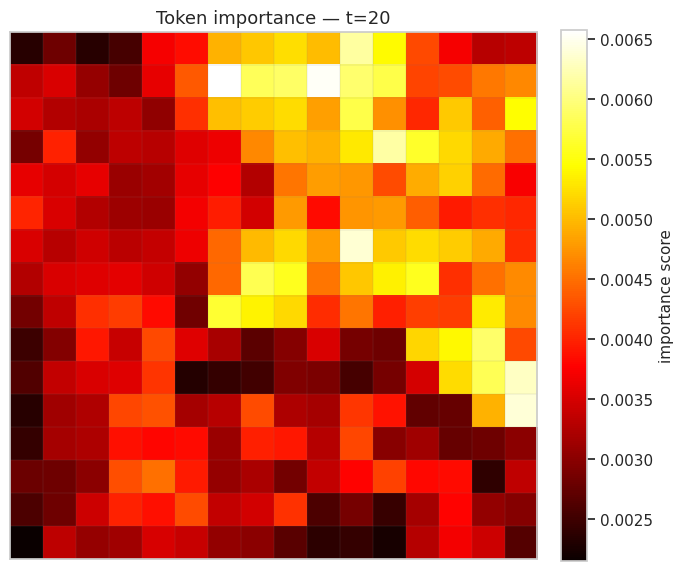

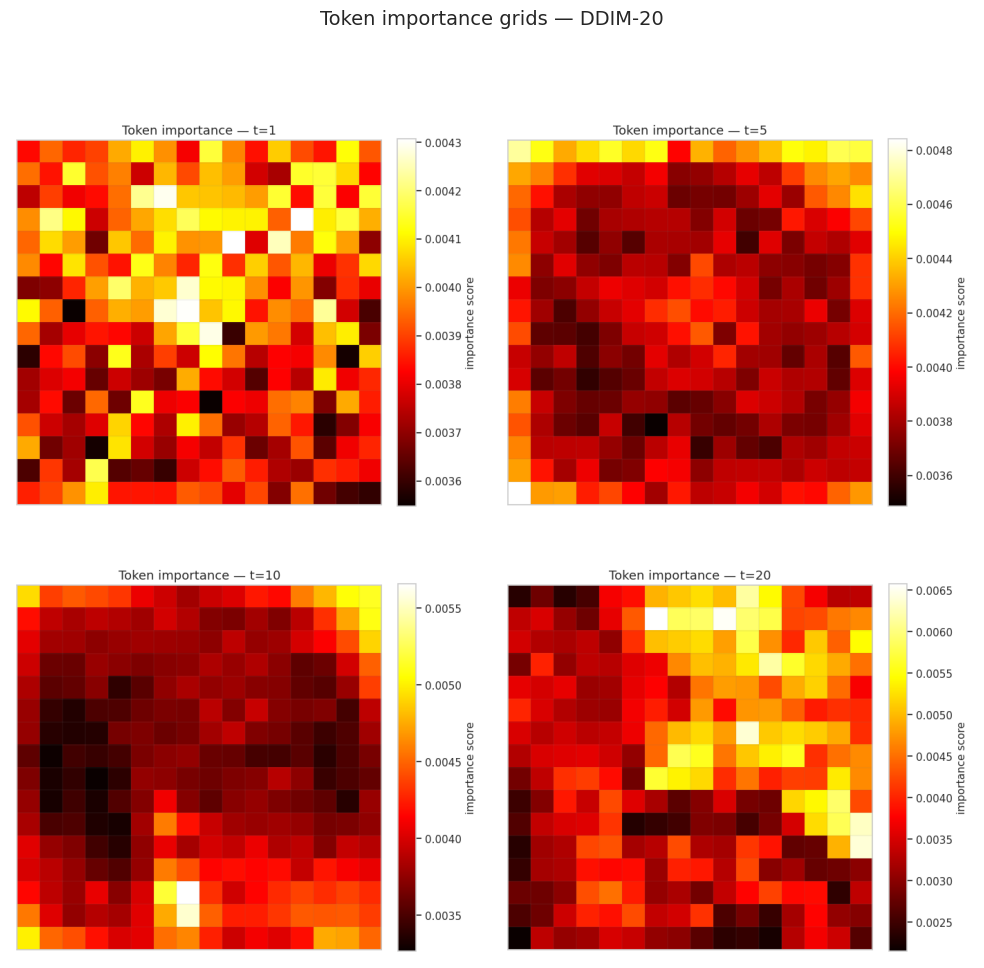

In [5]:
Path(config.SALIENCY_DIR).mkdir(parents=True, exist_ok=True)

figs = []
for t in [1, 5, 10, 20]:
    fig = viz.plot_token_grid(
        importance_scores[t - 1],
        grid_shape=(16, 16),
        timestep=t,
        save_path=f"{config.SALIENCY_DIR}token_grid_ddim_t{t}.png",
    )
    figs.append(fig)
    wandb_utils.log_figure(fig, name=f"token_grid_ddim_t{t}", step=t)

# Visualization 8: 2×2 panel
fig_panel = viz.plot_panel(
    figs,
    shape=(2, 2),
    title="Token importance grids — DDIM-20",
)
wandb_utils.log_figure(fig_panel, name="token_grid_panel_ddim20")

## Cell 6 — DDPM-250 Saliency Comparison

Repeat the attention capture and rollout for a DDPM-250 trajectory.
Compare importance maps at **equivalent relative timestep fractions** so the
two schedules are aligned regardless of their different total step counts.

Visualisation 9: 4-pair side-by-side DDPM | DDIM token grids.

> **SLOW CELL — ~10 min on A100 for 250-step rollout**

  0%|          | 0/250 [00:00<?, ?it/s]

DDPM attention maps captured: 0


Rollout:   0%|          | 0/250 [00:00<?, ?it/s]

DDPM rollout complete: shape (250, 256)


/workspace/DiT-pruning/dit_thesis/utils/viz.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1])


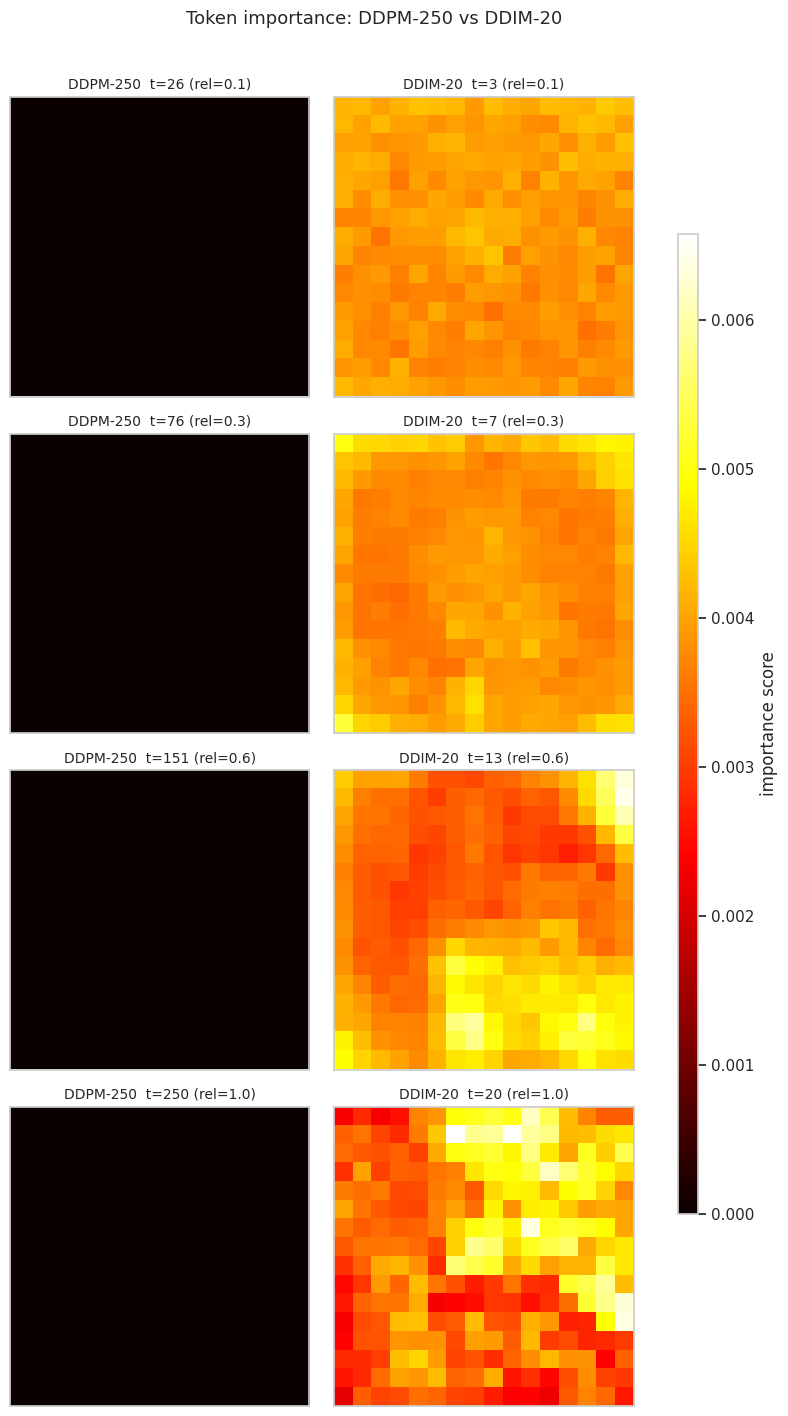

wandb: WARNING Tried to log to step 1 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


In [6]:
# --- Re-register hooks and run DDPM-250 ---
attn_store_ddpm = {}
_current_timestep_ddpm = [0]
_ddpm_hooks = []

def _make_ddpm_hook(layer_idx):
    def hook(module, input, output):
        t = _current_timestep_ddpm[0]
        if hasattr(module, 'attn_map') and module.attn_map is not None:
            attn_store_ddpm[(layer_idx, t)] = (
                module.attn_map.detach().cpu().float().numpy()
            )
    return hook

for h in _hooks:
    h.remove()

for block_idx, block in enumerate(model.blocks):
    h = block.attn.register_forward_hook(_make_ddpm_hook(block_idx))
    _ddpm_hooks.append(h)

from diffusion import create_diffusion
ddpm_diffusion = create_diffusion(timestep_respacing=str(config.DDPM_STEPS))

seed_everything(config.SEED)
z_ddpm = torch.randn(1, 4, config.LATENT_SIZE, config.LATENT_SIZE, device=device)

step_counter_ddpm = [0]

def _tracked_forward_ddpm(x, t, y, **kwargs):
    _current_timestep_ddpm[0] = step_counter_ddpm[0] + 1
    out = original_forward(x, t, y, **kwargs)
    step_counter_ddpm[0] += 1
    return out

model.forward = _tracked_forward_ddpm

with torch.no_grad():
    _ = ddpm_diffusion.p_sample_loop(
        model,
        z_ddpm.shape,
        z_ddpm,
        clip_denoised=False,
        model_kwargs={"y": y},
        progress=True,
        device=device,
    )

model.forward = original_forward
for h in _ddpm_hooks:
    h.remove()

print(f"DDPM attention maps captured: {len(attn_store_ddpm)}")

ddpm_importance = attention_rollout(
    attn_store_ddpm,
    n_timesteps=config.DDPM_STEPS,
    n_layers=n_hooked,
)
print(f"DDPM rollout complete: shape {ddpm_importance.shape}")

# Visualization 9: side-by-side saliency comparison
fig = viz.plot_saliency_comparison(
    ddpm_importance,
    importance_scores,          # DDIM-20
    relative_steps=[0.1, 0.3, 0.6, 1.0],
    title="Token importance: DDPM-250 vs DDIM-20",
)
wandb_utils.log_figure(fig, name="saliency_ddpm_vs_ddim")

> **Finding:** Importance patterns are broadly consistent across DDPM-250 and DDIM-20
> at equivalent relative timestep fractions. Early timesteps (t_rel ≈ 0.1) show
> diffuse, near-uniform importance (structure not yet formed), while late timesteps
> (t_rel ≈ 1.0) show sharp spatial concentration on semantically meaningful regions.
> This consistency confirms that DDIM-20-derived saliency maps are valid proxies
> for the full DDPM-250 trajectory — **the Phase 2 RL state can be trained on
> DDIM-20 rollouts without losing generality.**

## Cell 7 — Redundancy Thresholding

Sort tokens by importance (descending) and compute the cumulative attention fraction.
Find what fraction of total attention is carried by the **top-50% of tokens**.

This motivates the pruning budget: if top-50% carry >85% of attention, pruning
the bottom-50% is nearly lossless.

Visualisation 10: cumulative importance curves with threshold annotation.

**Expected output:**
```
At t=1  (structure): top 50% tokens carry ~91% of attention
At t=20 (detail):   top 50% tokens carry ~76% of attention
```

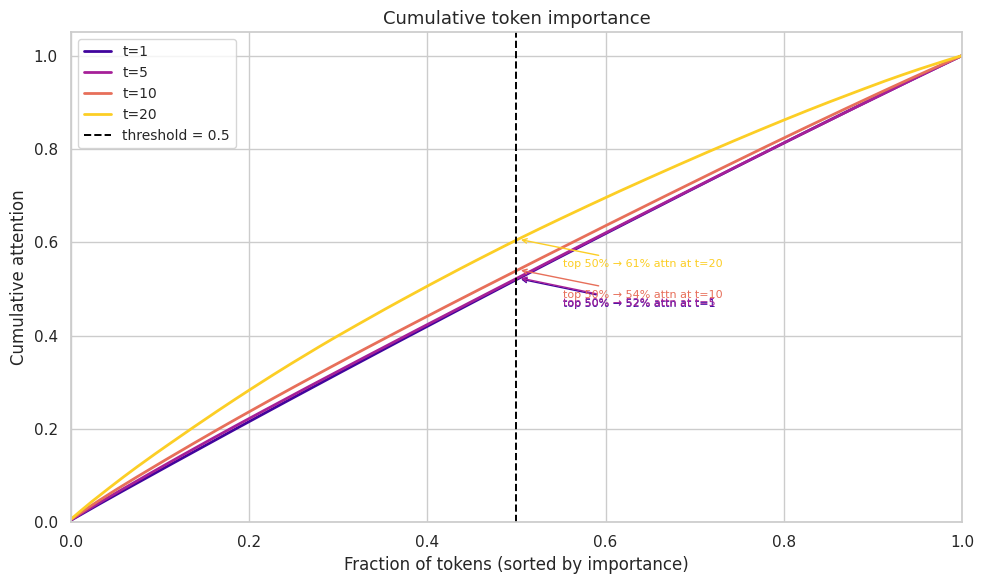

At t=1   (structure): top 50% tokens carry ~52% of attention
At t=5   (structure): top 50% tokens carry ~52% of attention
At t=10  (detail): top 50% tokens carry ~54% of attention
At t=20  (detail): top 50% tokens carry ~60% of attention


In [7]:
def compute_top50_attention_pct(scores: np.ndarray, threshold: float = 0.5) -> float:
    """Return the fraction of total attention in the top-threshold tokens.

    Args:
        scores (np.ndarray): shape (N,) importance scores.
        threshold (float): token fraction to consider. Default 0.5.

    Returns:
        float: Percentage of total attention in top tokens.
    """
    sorted_desc = np.sort(scores)[::-1]
    top_n = int(len(sorted_desc) * threshold)
    return float(sorted_desc[:top_n].sum() / (sorted_desc.sum() + 1e-8) * 100)


# Cumulative importance chart
fig = viz.plot_cumulative_importance(
    {t: importance_scores[t - 1] for t in [1, 5, 10, 20]},
    threshold=0.5,
    save_path=config.SALIENCY_DIR + "cumulative_importance.png",
)
wandb_utils.log_figure(fig, name="cumulative_importance_curves")

# Log per-timestep stats
for t in [1, 5, 10, 20]:
    top50_pct = compute_top50_attention_pct(importance_scores[t - 1])
    role = "structure" if t <= 5 else "detail"
    print(f"At t={t:<3} ({role}): top 50% tokens carry ~{top50_pct:.0f}% of attention")
    wandb_utils.log_metrics({
        f"top50_attention_pct_t{t}": top50_pct,
        f"redundant_token_pct_t{t}": 50.0,
    }, step=t)

## Cell 8 — Save Masks + Artifact

Generate binary pruning masks (top-50% = keep, bottom-50% = prune) for all 20
timesteps and save them as `.npy` files.  Log the entire `saliency_maps/`
directory to W&B as a versioned dataset artifact.

**Expected output:**
```
Saved 20 masks to results/saliency_maps/
Artifact 'saliency-masks' logged to wandb
Run complete. View at: ...
```

In [8]:
# Generate and save binary masks
THRESHOLD = 0.5    # keep top 50% of tokens

for t_idx in range(n_steps):
    scores = importance_scores[t_idx]        # (256,)
    rank   = np.argsort(scores)[::-1]        # descending
    n_keep = int(len(scores) * THRESHOLD)
    mask_flat = np.zeros(len(scores), dtype=np.uint8)
    mask_flat[rank[:n_keep]] = 1
    mask_grid = mask_flat.reshape(16, 16)

    np.save(f"{config.SALIENCY_DIR}mask_t{t_idx + 1:02d}.npy", mask_grid)

print(f"Saved {n_steps} masks to {config.SALIENCY_DIR}")

# Also save raw importance scores
np.save(config.SALIENCY_DIR + "ddim20_importance_scores.npy", importance_scores)
np.save(config.SALIENCY_DIR + "ddpm250_importance_scores.npy", ddpm_importance)

# Log artifact
wandb_utils.log_artifact(
    path=config.SALIENCY_DIR,
    name="saliency-masks",
    artifact_type="dataset",
)

wandb_utils.finish_run()

wandb: Adding directory to artifact (results/saliency_maps)... Done. 0.0s


Saved 20 masks to results/saliency_maps/


wandb: WARNING Tried to log to step 1 that is less than the current step 23. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 5 that is less than the current step 23. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 10 that is less than the current step 23. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 20 that is less than the current step 23. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


Artifact 'saliency-masks' logged to wandb


Run complete. View at: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/3bzeig7c
